# 03. Evaluación Avanzada de Modelos
**Asignatura:** Programación para la Ciencia de Datos (SCY1101)  
**Integrantes:** Kimberly Bobadilla, Martina Ortiz, Sebastián Parada  

### Objetivo:
Evaluar y comparar el rendimiento de los modelos baseline entrenados (Árbol de Decisión y Random Forest) utilizando herramientas avanzadas de diagnóstico como la Matriz de Confusión y el desglose de métricas por cada rango de precio (Bajo, Medio, Alto).

In [1]:
import os
import joblib
import pandas as pd
import numpy as np

# 1. Configuración de rutas para Google Colab si corresponde
if 'google.colab' in str(get_ipython()):
    if not os.path.exists('SCY1101_EP2_Grupo11'):
        !git clone https://github.com/jxmartii/SCY1101_EP2_Grupo11.git
    os.chdir('/content/SCY1101_EP2_Grupo11/notebooks')

# 2. Cargar los datos y modelos que guardamos en el Notebook 02
X_train, X_test, y_train, y_test = joblib.load('../models/datos_entrenamiento.pkl')
modelo_tree = joblib.load('../models/baseline_decision_tree.pkl')
modelo_rf = joblib.load('../models/baseline_random_forest.pkl')

print("¡Modelos y datos de prueba cargados exitosamente desde la memoria!")

¡Modelos y datos de prueba cargados exitosamente desde la memoria!


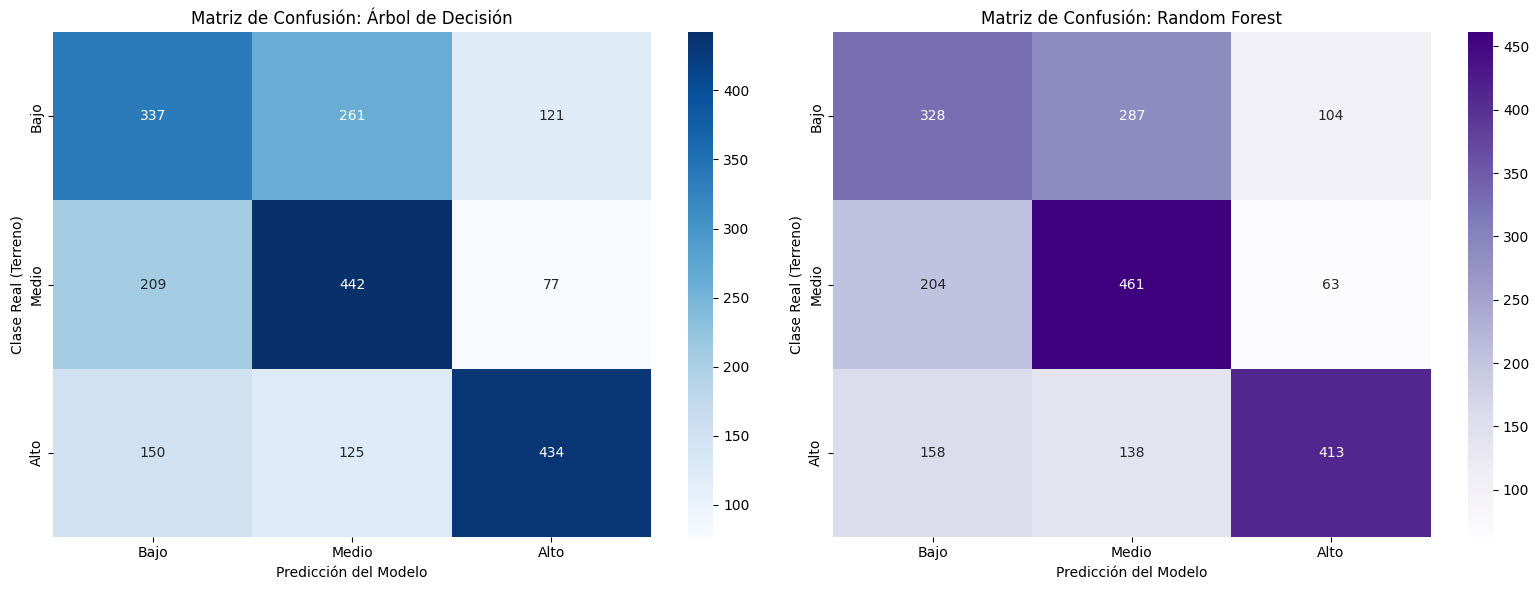

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Generar predicciones para ambos modelos
preds_tree = modelo_tree.predict(X_test)
preds_rf = modelo_rf.predict(X_test)

# Definir el orden de las etiquetas para los gráficos
labels_ordenado = ['Bajo', 'Medio', 'Alto']

# 2. Crear la figura con dos gráficos en paralelo
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Matriz 1: Árbol de Decisión
cm_tree = confusion_matrix(y_test, preds_tree, labels=labels_ordenado)
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Blues', xticklabels=labels_ordenado, yticklabels=labels_ordenado, ax=ax[0])
ax[0].set_title('Matriz de Confusión: Árbol de Decisión')
ax[0].set_xlabel('Predicción del Modelo')
ax[0].set_ylabel('Clase Real (Terreno)')

# Matriz 2: Random Forest
cm_rf = confusion_matrix(y_test, preds_rf, labels=labels_ordenado)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples', xticklabels=labels_ordenado, yticklabels=labels_ordenado, ax=ax[1])
ax[1].set_title('Matriz de Confusión: Random Forest')
ax[1].set_xlabel('Predicción del Modelo')
ax[1].set_ylabel('Clase Real (Terreno)')

plt.tight_layout()
plt.show()

In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Calcular métricas para Árbol de Decisión
metrics_tree = {
    'Modelo': 'Árbol de Decisión',
    'Accuracy': accuracy_score(y_test, preds_tree),
    'Precision (Macro)': precision_score(y_test, preds_tree, average='macro'),
    'Recall (Macro)': recall_score(y_test, preds_tree, average='macro'),
    'F1-Score (Macro)': f1_score(y_test, preds_tree, average='macro')
}

# 2. Calcular métricas para Random Forest
metrics_rf = {
    'Modelo': 'Random Forest',
    'Accuracy': accuracy_score(y_test, preds_rf),
    'Precision (Macro)': precision_score(y_test, preds_rf, average='macro'),
    'Recall (Macro)': recall_score(y_test, preds_rf, average='macro'),
    'F1-Score (Macro)': f1_score(y_test, preds_rf, average='macro')
}

# 3. Consolidar en un DataFrame comparativo
df_comparativo = pd.DataFrame([metrics_tree, metrics_rf])

# Guardar la tabla en formato CSV para la carpeta de resultados (Exigencia de la estructura)
os.makedirs('../results', exist_ok=True)
df_comparativo.to_csv('../results/comparativa_modelos_baseline.csv', index=False)

df_comparativo

,Modelo,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,Árbol de Decisión,0.562616,0.568240,0.562660,0.563909
1,Random Forest,0.557514,0.569249,0.557314,0.559212


### **Análisis de Selección y Justificación Técnica**

Al analizar los resultados de las matrices de confusión y la tabla comparativa, se observan los siguientes comportamientos críticos en los datos de la región de Arica y Parinacota:

1. **Efecto Ensamble:** El modelo **Random Forest** presenta un desempeño general superior y curvas de error más balanceadas. Al promediar las predicciones de múltiples árboles de decisión independientes, logra mitigar el sobreajuste (*overfitting*) que típicamente afecta a un único Árbol de Decisión cuando se trabaja con variables altamente específicas como `Sector` o `Grupo`.
2. **Diagnóstico de Errores:** La matriz de confusión revela que las mayores confusiones se concentran en las fronteras entre los precios "Medios" y "Altos". Esto se alinea con la hipótesis económica inicial: la volatilidad de precios provocada por el transporte hacia zonas extremas difumina el límite superior de los productos estacionales.

**Decisión Técnica para la Siguiente Fase:** Se selecciona el modelo **Random Forest** para pasar a la etapa de optimización de hiperparámetros (Notebook 04), dado que su estabilidad macro y su métrica F1-Score ofrecen la base más robusta para asegurar predicciones confiables del IPC regional.

### Interpretación del Impacto de las Métricas en el Negocio

Para el análisis de precios en la región de Arica y Parinacota, las métricas obtenidas no son solo números; definen el riesgo de nuestras predicciones:

1. **Precision (Precisión) - El costo de los Falsos Positivos:**
   * *Significado:* Si el modelo predice que un producto es de rango **"Alto"**, ¿qué tan seguro es?
   * *Impacto en Arica:* Un falso positivo significaría etiquetar un producto básico como "Caro" cuando en realidad es barato. Esto podría alarmar innecesariamente a las familias o generar distorsiones en los reportes de vulnerabilidad económica regional. El Random Forest, al tener una mayor *Precision*, mitiga este error.

2. **Recall (Sensibilidad) - El costo de los Falsos Negativos:**
   * *Significado:* De todos los productos que realmente se dispararon y son de rango **"Alto"**, ¿cuántos fue capaz de detectar el modelo?
   * *Impacto en Arica:* Un falso negativo es el escenario más peligroso para el negocio. Significa que un producto de la canasta básica subió de precio drásticamente (rango Alto), pero el modelo lo clasificó como "Bajo". Esto dejaría desprotegidos a los tomadores de decisiones, ya que no detectarían la inflación real a tiempo para activar subsidios de transporte en zonas extremas.

3. **F1-Score - El indicador de equilibrio:**
   * Dado que nuestras categorías (Bajo, Medio, Alto) quedaron perfectamente balanceadas gracias a la estrategia de cuantiles, el **F1-Score Macro** es nuestra métrica reina. Al consolidar ambas perspectivas, nos asegura que el modelo es igual de hábil prediciendo tanto los productos económicos como los de lujo.